In [ ]:
import datetime as dt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import sklearn

from pathlib import Path
import os
import warnings

os.chdir("..")
pd.set_option("display.max_columns", None)

# Loading data

In [2]:
data_path = Path("data/merged/merged_v6.csv")

data = pd.read_csv(data_path)
data["time"] = pd.to_datetime(data["time"], utc=True).dt.tz_convert("Europe/Kyiv")

In [3]:
data.head(3)

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day
0,2,2022-03-28 00:00:00+03:00,0,0.4,-2.2,43.82,-10.5,0.0,0.0,0,7.6,314.0,1029.0,24.1,2.0,0.0,0,13,5,0,0,4,4,0,0,0,0,0,0,5,5,5,4,0,86,289,-3,0,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
1,2,2022-03-28 01:00:00+03:00,0,-0.1,-2.5,45.43,-10.5,0.0,0.0,0,6.8,308.6,1029.0,24.1,4.2,0.0,0,8,2,0,0,3,3,0,0,0,0,0,0,1,1,1,4,0,45,285,-3,1,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28
2,2,2022-03-28 02:00:00+03:00,0,-0.6,-2.3,47.87,-10.3,0.0,0.0,0,5.0,305.7,1029.0,24.1,3.1,0.0,0,7,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,28,269,-2,2,0,0,13953,0,0,0,0,0,0,0,0,0,1,1,0.345617,7,0.59827,0.589003,28,0,0.22995,0.396254,0.714286,3,0.565055,29,0.724138,2022,3,28


In [4]:
data.isna().sum().sum()

np.int64(0)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 734233 entries, 0 to 734232
Data columns (total 68 columns):
 #   Column                     Non-Null Count   Dtype                      
---  ------                     --------------   -----                      
 0   region_id                  734233 non-null  int64                      
 1   time                       734233 non-null  datetime64[us, Europe/Kyiv]
 2   alarm                      734233 non-null  int64                      
 3   hour_temp                  734233 non-null  float64                    
 4   hour_feelslike             734233 non-null  float64                    
 5   hour_humidity              734233 non-null  float64                    
 6   hour_dew                   734233 non-null  float64                    
 7   hour_precip                734233 non-null  float64                    
 8   hour_precipprob            734233 non-null  float64                    
 9   hour_preciptype            734233 non-null  int6

In [6]:
data[["hour_preciptype", "hour_conditions"]].nunique()

hour_preciptype     6
hour_conditions    16
dtype: int64

In [7]:
print(f"Percent of alarms: {data["alarm"].sum() / len(data):.2%}")

Percent of alarms: 22.32%


In [8]:
data.agg(["min", "max", "mean", "std"])

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day
min,2.000000,2022-02-24 07:00:00+02:00,0.000000,-26.100000,-33.100000,10.170000,-28.400000,0.000000,0.000000,0.000000,0.000000,0.000000,973.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,-31.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.108198,3.000000,2.162327e-08,2.162327e-08,-8.000000,-3.000000,0.065127,0.207121,0.400000,2.000000,0.115810,18.000000,0.416667,2022.000000,1.000000,1.000000
max,24.000000,2026-03-11 18:00:00+02:00,1.000000,39.400000,42.200000,100.000000,24.600000,300.000000,100.000000,5.000000,90.000000,639.000000,1050.000000,75.000000,100.000000,10.000000,15.000000,217.000000,48.000000,12.000000,64.000000,119.000000,118.000000,11.000000,10.000000,17.000000,23.000000,23.000000,23.000000,105.000000,105.000000,105.000000,118.000000,23.000000,386.000000,1414.000000,31.000000,23.000000,6.000000,1.000000,113586.000000,2.000000,2.00000,2.000000,2.000000,1.000000,2.000000,2.000000,3.000000,2.000000,2.000000,1.0,0.464887,7.000000,1.078992e+00,1.028184e+00,28.000000,3.000000,0.673703,0.500972,1.000000,3.000000,0.696373,30.000000,1.000000,2026.000000,12.000000,31.000000
mean,13.254140,2024-02-26 12:15:15.208115+02:00,0.223169,10.519089,9.036238,73.209439,5.155593,0.084351,8.129981,0.449243,11.439622,196.462581,1016.742658,13.918103,62.610369,1.405031,3.193433,9.994164,2.287411,0.609426,1.024295,3.543146,2.982057,0.696463,0.785872,0.950704,0.828909,0.828189,0.828218,3.059925,3.056338,3.516147,3.042218,1.052644,29.979742,239.761472,0.000612,11.502211,2.999359,0.285623,31425.773192,0.115320,0.11964,0.133797,0.126532,0.043866,0.094727,0.087835,0.170178,0.123530,0.107083,1.0,0.277606,5.941468,2.330790e-01,3.455685e-01,0.288867,-0.021653,0.266326,0.376267,0.900269,2.962933,0.348749,25.514489,0.875491,2023.656915,6.487106,15.690665
std,6.900417,423 days 20:27:22.961199,0.416371,9.874121,11.415975,19.469309,7.733428,1.967041,27.329517,1.270631,6.505238,111.709828,8.468804,10.173708,38.090741,2.214415,2.368814,11.568283,3.347485,1.140763,3.043636,5.960497,5.522676,1.379875,1.311951,1.627915,1.583693,1.583445,1.583439,5.173276,5.171483,5.523587,5.554856,1.761428,27.296339,141.905495,3.177910,6.920961,1.999972,0.451711,22415.468109,0.380237,0.36079,0.423072,0.340511,0.204797,0.362020,0.336257,0.450551,0.331026,0.373561,0.0,0.061722,0.969158,2.731537e-01,2.399610e-01,3.479454,1.072220,0.107960,0.055701,0.127656,0.188927,0.107831,2.864718,0.114837,1.185137,3.452805,8.817157


In [45]:

target = "alarm"

X = data.copy()
# X = X.loc[X.year < 2026]
y = X.pop(target)

# X["year"] = X["time"].dt.year
# X["month"] = X["time"].dt.month
# X["day"] = X["time"].dt.day

In [46]:
cat_cols = ["hour_preciptype", "hour_conditions", "is_weekend", "cluster", ]
num_cols = [col for col in X.select_dtypes(include="number").columns if col not in cat_cols]

print(f"Categorical columns:\n{cat_cols}")
print("-"*20)
print(f"Numerical columns:\n{num_cols}")

Categorical columns:
['hour_preciptype', 'hour_conditions', 'is_weekend', 'cluster']
--------------------
Numerical columns:
['region_id', 'hour_temp', 'hour_feelslike', 'hour_humidity', 'hour_dew', 'hour_precip', 'hour_precipprob', 'hour_windspeed', 'hour_winddir', 'hour_pressure', 'hour_visibility', 'hour_cloudcover', 'hour_uvindex', 'messages_count', 'has_threat_sum', 'nlp_артобстрілу', 'nlp_бпла', 'nlp_відбій', 'nlp_відбій_тривоги', 'nlp_дніпропетровська', 'nlp_донецька', 'nlp_запорізька', 'nlp_нікополь', 'nlp_нікополь_нікопольська', 'nlp_нікопольська', 'nlp_повітряна', 'nlp_повітряна_тривога', 'nlp_тривога', 'nlp_тривоги', 'nlp_харківська', 'msg_count_last_3h', 'msg_count_last_24h', 'threat_diff_1h', 'hour_of_day', 'day_of_week', 'text_length', 'isw_cluster_0', 'isw_cluster_1', 'isw_cluster_2', 'isw_cluster_3', 'isw_cluster_4', 'isw_cluster_5', 'isw_cluster_6', 'isw_cluster_7', 'isw_cluster_8', 'isw_cluster_9', 'anomaly_count_7d', 'avg_dist_centroid_7d', 'news_count_7d', 'topic_en

# Evaluation function with TimeSeries split

In [81]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import TimeSeriesSplit, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone
from time import time

cat_cols = ["hour_preciptype", "hour_conditions", "is_weekend", "cluster", ]
num_cols = [col for col in X.select_dtypes(include="number").columns if col not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), num_cols)
], remainder='passthrough')

def exponential_weights(n, half_life):
    """
    Assign exponentially decaying weights.
    half_life: number of periods after which weight halves.
    """
    decay = np.log(2) / half_life
    indices = np.arange(n)
    weights = np.exp(-decay * (n - 1 - indices))  # recent = highest weight
    return weights / weights.sum()


def train_evaluate_model(model, X=X, y=y, preprocessor=preprocessor, 
                         n_splits: int = 5, max_train_size=None, gap=0,
                         use_sample_weights: bool = False, half_life: int = 90,
                        ):
    if max_train_size:
        test_size=max_train_size // 100 * 20
    else:
        test_size=None
    
    spliter = TimeSeriesSplit(n_splits=n_splits, gap=gap, max_train_size=max_train_size, test_size=test_size)

    unique_hours = X["time"].sort_values().unique()
    train_auprc_scores = []
    train_mcc_scores = []
    test_auprc_scores = []
    test_mcc_scores = []
    all_y_true = []
    all_y_pred = []
    fold_cms = []

    training_start = time()
    n_splits = spliter.get_n_splits()

    fig, axes = plt.subplots(
        nrows=n_splits,
        ncols=2,
        figsize=(10, n_splits * 4),
        gridspec_kw={"width_ratios": [2, 1]}
    )

    if preprocessor:
        model = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

    for fold, (train_idx, test_idx) in enumerate(spliter.split(unique_hours)):
        fold_start = time()
        print(f"------------- Fold {fold} -------------")

        train_hours = unique_hours[train_idx]
        test_hours = unique_hours[test_idx]

        train_mask = X["time"].isin(train_hours)
        test_mask = X["time"].isin(test_hours)
        X_train = X[train_mask].drop(columns=["time"])
        y_train = y[train_mask]
        X_test = X[test_mask].drop(columns=["time"])
        y_test = y[test_mask]

        print("Time range")
        print(f"Train: {train_hours.min()} - {train_hours.max()}, len={len(train_hours)}")
        print(f"Test:  {test_hours.min()} - {test_hours.max()}, len={len(test_hours)}")
        print()
        print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
        print(f"Train positive rate: {y_train.mean():.3f}, Test positive rate: {y_test.mean():.3f}")
        print()

        if use_sample_weights:
            weights = exponential_weights(len(X_train), half_life=half_life)
        else:
            weights = None

        print("Training...", end=" ")
        if preprocessor:
            model.fit(X_train, y_train, model__sample_weight=weights)
        else:
            model.fit(X_train, y_train, sample_weight=weights)
        print("Done.")
        print("Evaluating...", end=" ")

        y_prob_train = model.decision_function(X_train)
        train_auprc = average_precision_score(y_train, y_prob_train)
        train_auprc_scores.append(train_auprc)
        y_pred_train = model.predict(X_train)
        train_mcc = matthews_corrcoef(y_train, y_pred_train)
        train_mcc_scores.append(train_mcc)

        y_prob_test = model.decision_function(X_test)
        test_auprc = average_precision_score(y_test, y_prob_test)
        test_auprc_scores.append(test_auprc)
        y_pred_test = model.predict(X_test)
        test_mcc = matthews_corrcoef(y_test, y_pred_test)
        test_mcc_scores.append(test_mcc)

        print("Done.")
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred_test)

        cm = confusion_matrix(y_test, y_pred_test)
        fold_cms.append(cm)

        print(f"Completed in {time() - fold_start:.2f}s.")

        # --- Left subplot: score line plot ---
        ax_line = axes[fold, 0]
        fold_scores = pd.DataFrame({
            "Train AUPRC": train_auprc_scores,
            "Test AUPRC":  test_auprc_scores,
            "Train MCC":   train_mcc_scores,
            "Test MCC":    test_mcc_scores,
        })
        sns.lineplot(data=fold_scores, ax=ax_line, markers=True, dashes=False)
        ax_line.set_title(f"Fold {fold} — scores up to current fold", fontsize=11)
        ax_line.set_xlabel("Fold")
        ax_line.set_ylabel("Score")
        ax_line.set_xticks(range(len(fold_scores)))
        ax_line.legend(loc="lower left", fontsize=8)
        ax_line.set_ylim(0, 1)

        # --- Right subplot: confusion matrix ---
        ax_cm = axes[fold, 1]
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=ax_cm,
            cbar=False,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"],
        )
        ax_cm.set_title(
            f"Fold {fold} — confusion matrix\n"
            f"AUPRC {test_auprc:.3f}  MCC {test_mcc:.3f}",
            fontsize=10,
        )

    plt.suptitle("Per-fold evaluation", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    
    print("\n------------- Completed -------------")
    print(f"Train AUPRC : {np.mean(train_auprc_scores):.3f} ± {np.std(train_auprc_scores):.3f}")
    print(f"Test  AUPRC : {np.mean(test_auprc_scores):.3f} ± {np.std(test_auprc_scores):.3f}")
    print(f"Train MCC   : {np.mean(train_mcc_scores):.3f} ± {np.std(train_mcc_scores):.3f}")
    print(f"Test  MCC   : {np.mean(test_mcc_scores):.3f} ± {np.std(train_mcc_scores):.3f}")
    print(f"Completed in: {time() - training_start:.2f}s.")

    scores = pd.DataFrame({
        "train_auprc": train_auprc_scores,
        "test_auprc":  test_auprc_scores,
        "train_mcc":   train_mcc_scores,
        "test_mcc":    test_mcc_scores,
    })
    overall_cm = confusion_matrix(all_y_true, all_y_pred)

    return model, scores, overall_cm

LinearSVC without tunning parameters
------------- Fold 0 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2022-10-28 11:00:00+03:00, len=5908
Test:  2022-10-28 12:00:00+03:00 - 2023-07-01 13:00:00+03:00, len=5904

Train size: 5908, Test size: 5904
Train positive rate: 0.201, Test positive rate: 0.130

Training... Done.
Evaluating... Done.
Completed in 0.07s.
------------- Fold 1 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2023-07-01 13:00:00+03:00, len=11812
Test:  2023-07-01 14:00:00+03:00 - 2024-03-03 14:00:00+02:00, len=5904

Train size: 11812, Test size: 5904
Train positive rate: 0.166, Test positive rate: 0.206

Training... Done.
Evaluating... Done.
Completed in 0.11s.
------------- Fold 2 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2024-03-03 14:00:00+02:00, len=17716
Test:  2024-03-03 15:00:00+02:00 - 2024-11-04 16:00:00+02:00, len=5904

Train size: 17716, Test size: 5904
Train positive rate: 0.179, Test positive rate: 0.301

Training.

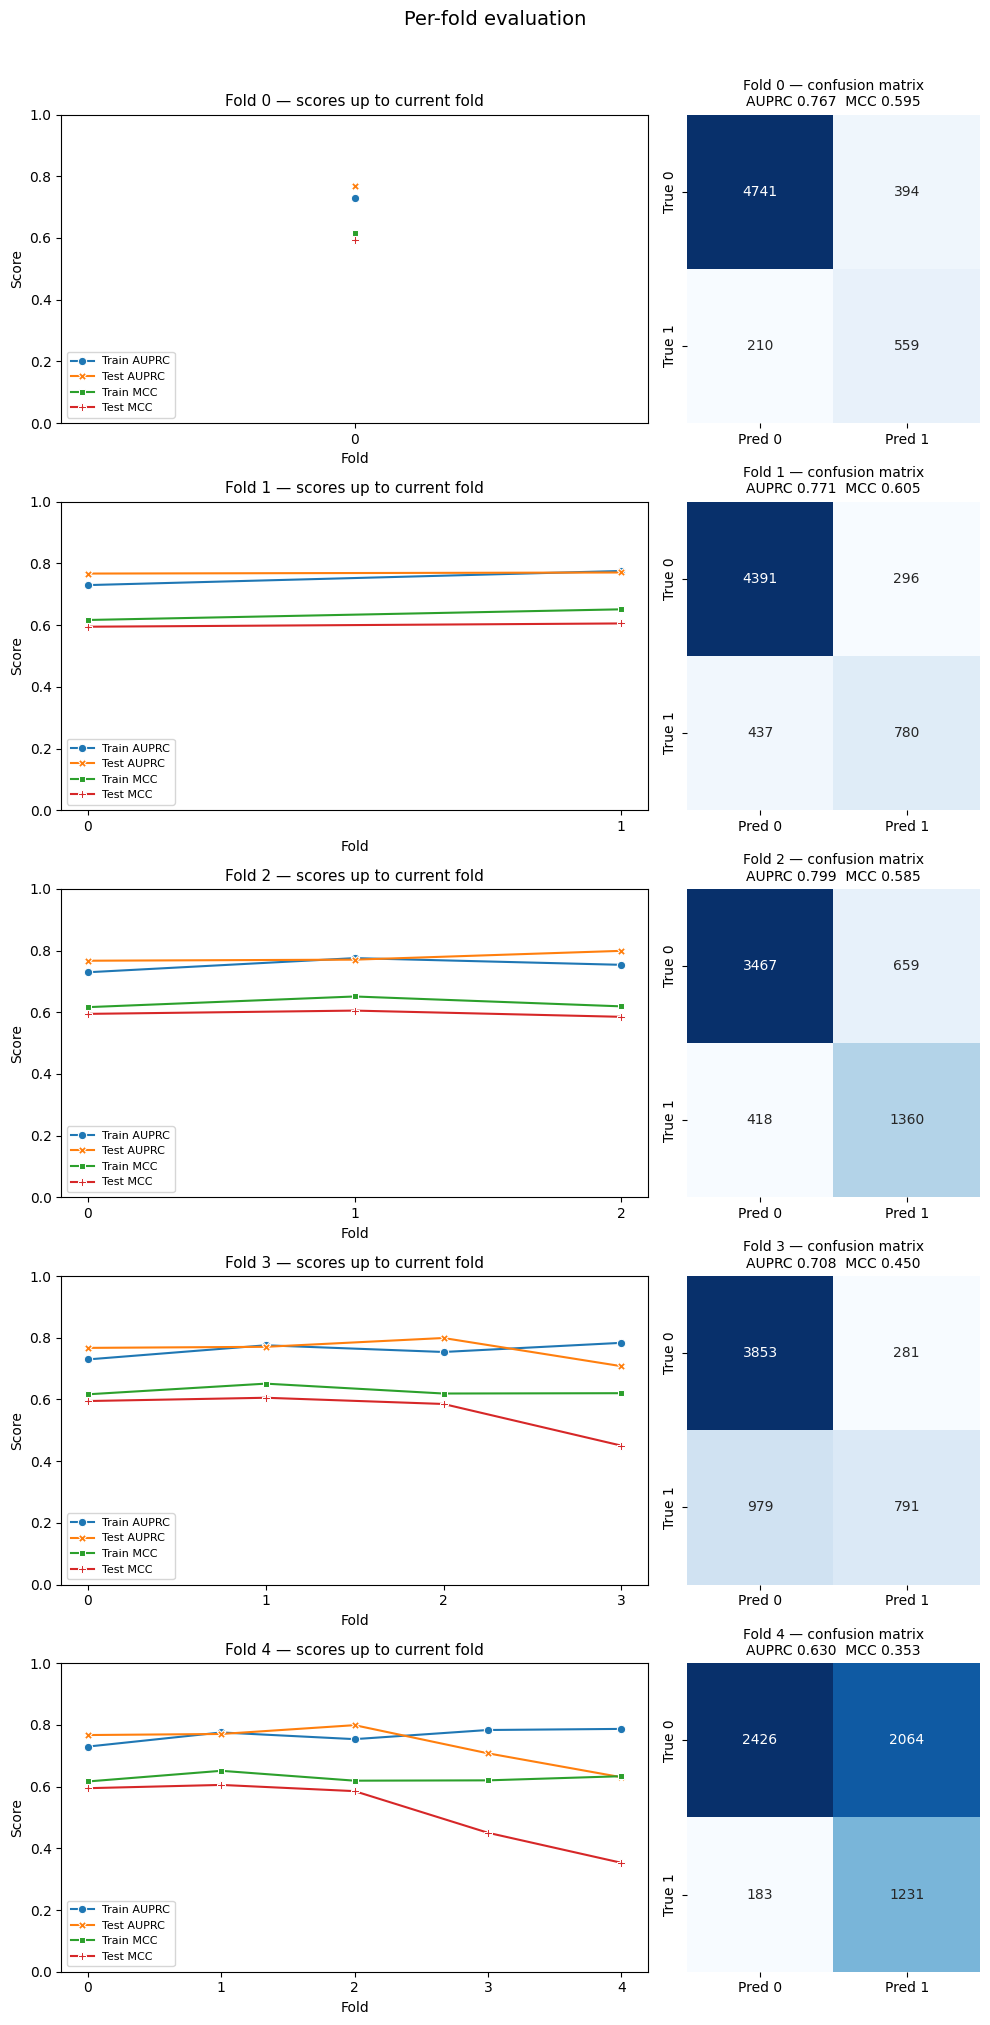


------------- Completed -------------
Train AUPRC : 0.766 ± 0.021
Test  AUPRC : 0.735 ± 0.060
Train MCC   : 0.628 ± 0.013
Test  MCC   : 0.518 ± 0.013
Completed in: 1.79s.


In [82]:
print("LinearSVC without tunning parameters")
X_1_reg = X.loc[X.region_id == 10]
y_1_reg = y.loc[X_1_reg.index]

model = SGDClassifier(random_state=42, shuffle=False)

model_raw, scores_raw, cm_raw = train_evaluate_model(model, X=X_1_reg, y=y_1_reg, preprocessor=preprocessor)

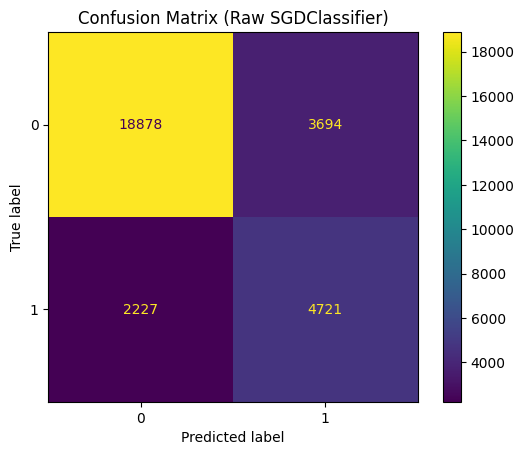

In [83]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_raw)
disp.plot()
plt.title("Confusion Matrix (Raw SGDClassifier)")
plt.show()

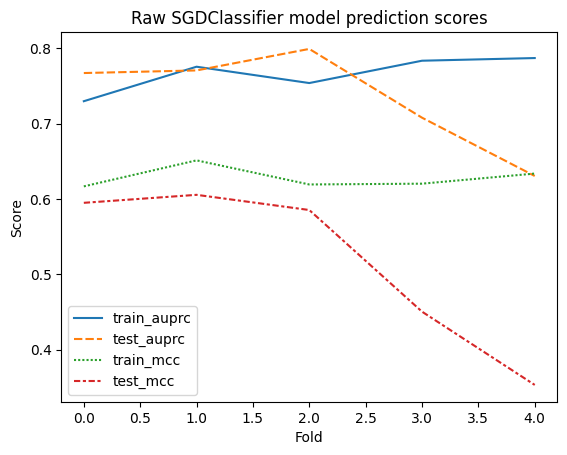

In [84]:
sns.lineplot(scores_raw)

plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Raw SGDClassifier model prediction scores")
plt.show()

**In TimeSeriesSplit each folder have more training data then previous, so more model trains - less test score it gets. Try training on more recent data to test set**

In [117]:
X.columns

Index(['region_id', 'time', 'hour_temp', 'hour_feelslike', 'hour_humidity',
       'hour_dew', 'hour_precip', 'hour_precipprob', 'hour_preciptype',
       'hour_windspeed', 'hour_winddir', 'hour_pressure', 'hour_visibility',
       'hour_cloudcover', 'hour_uvindex', 'hour_conditions', 'messages_count',
       'has_threat_sum', 'nlp_артобстрілу', 'nlp_бпла', 'nlp_відбій',
       'nlp_відбій_тривоги', 'nlp_дніпропетровська', 'nlp_донецька',
       'nlp_запорізька', 'nlp_нікополь', 'nlp_нікополь_нікопольська',
       'nlp_нікопольська', 'nlp_повітряна', 'nlp_повітряна_тривога',
       'nlp_тривога', 'nlp_тривоги', 'nlp_харківська', 'msg_count_last_3h',
       'msg_count_last_24h', 'threat_diff_1h', 'hour_of_day', 'day_of_week',
       'is_weekend', 'text_length', 'isw_cluster_0', 'isw_cluster_1',
       'isw_cluster_2', 'isw_cluster_3', 'isw_cluster_4', 'isw_cluster_5',
       'isw_cluster_6', 'isw_cluster_7', 'isw_cluster_8', 'isw_cluster_9',
       'anomaly_count_7d', 'avg_dist_centroid

------------- Fold 0 -------------
Time range
Train: 2024-09-18 08:00:00+03:00 - 2025-03-17 08:00:00+02:00, len=4320
Test:  2025-03-18 09:00:00+02:00 - 2025-04-23 05:00:00+03:00, len=860

Train size: 4320, Test size: 860
Train positive rate: nan, Test positive rate: nan

Training... 

ValueError: Found input variables with inconsistent numbers of samples: [4320, 0]

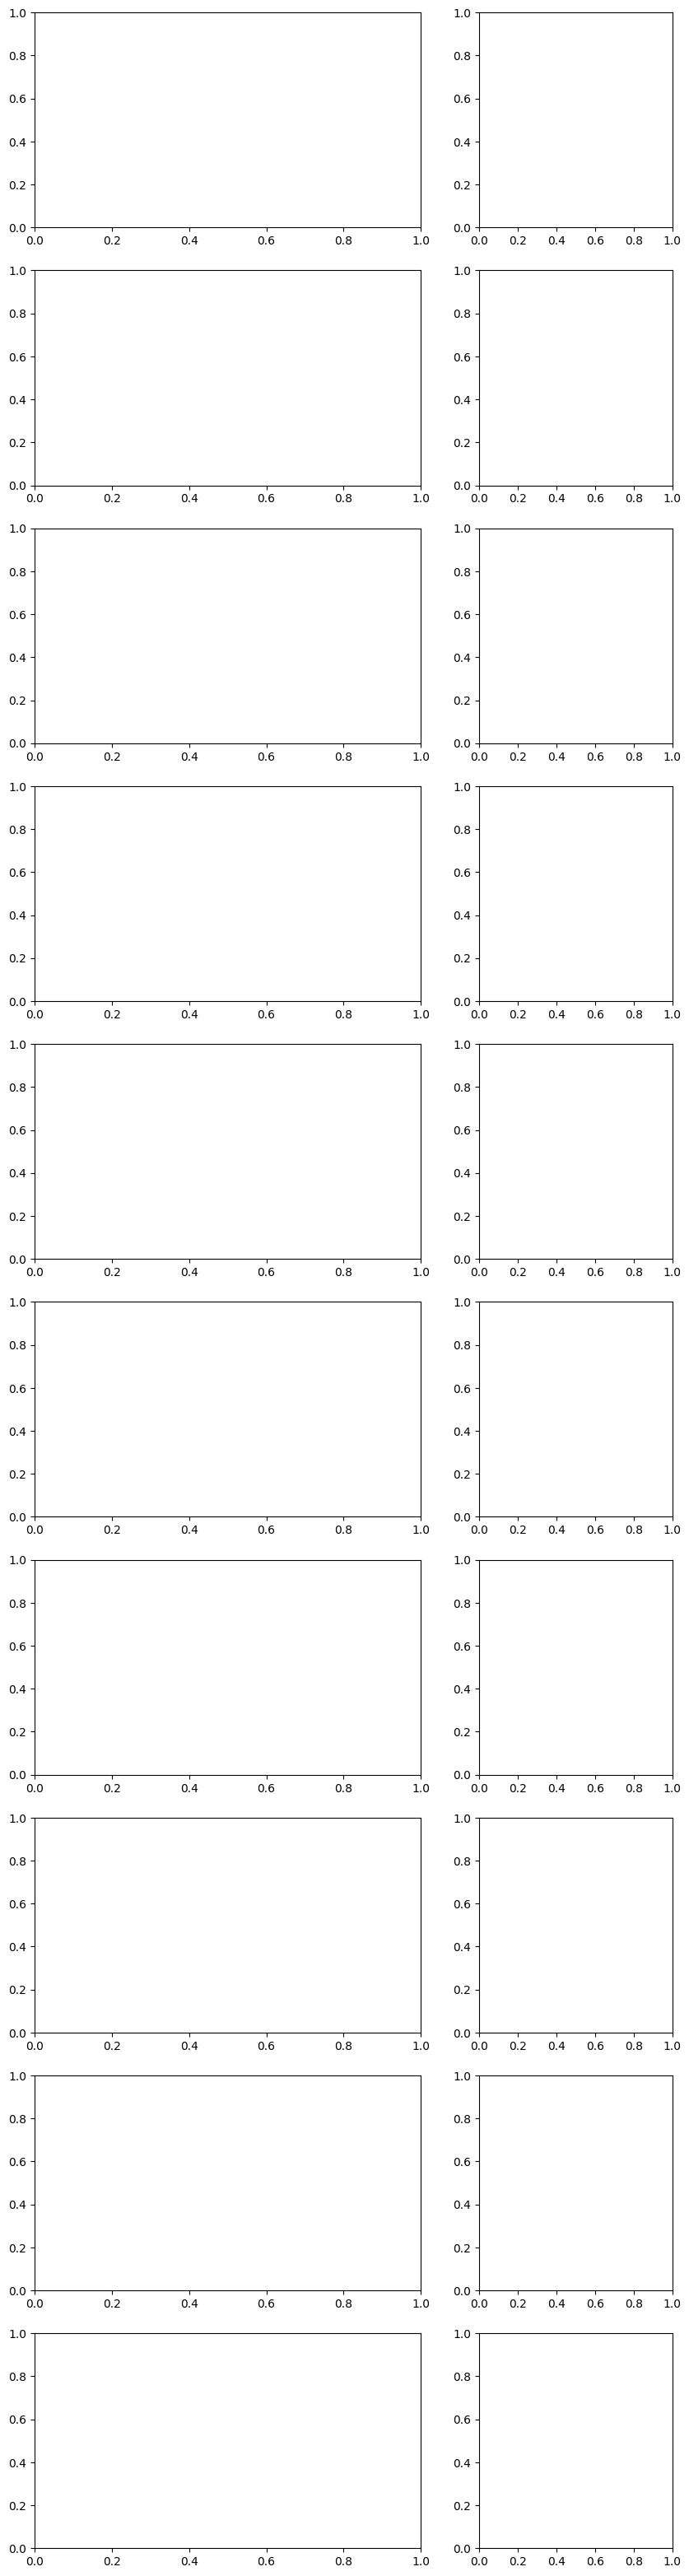

In [118]:
model = SGDClassifier(
    random_state=42,
    loss='modified_huber',
    shuffle=False,
    class_weight='balanced'
)

tg_cols = ['messages_count',
       'has_threat_sum', 'nlp_артобстрілу', 'nlp_бпла', 'nlp_відбій',
       'nlp_відбій_тривоги', 'nlp_дніпропетровська', 'nlp_донецька',
       'nlp_запорізька', 'nlp_нікополь', 'nlp_нікополь_нікопольська',
       'nlp_нікопольська', 'nlp_повітряна', 'nlp_повітряна_тривога',
       'nlp_тривога', 'nlp_тривоги', 'nlp_харківська', 'msg_count_last_3h',
       'msg_count_last_24h', 'threat_diff_1h']

X_test = X_1_reg.copy()
X_test[tg_cols] = X_test[tg_cols].shift(1).dropna(axis=0)

y_train = X_1_reg.loc[X_test.index]


_, scores, cm = train_evaluate_model(model, X=X_test, y=y_test, preprocessor=preprocessor, n_splits=10, max_train_size=180*24, gap=24, use_sample_weights=True)

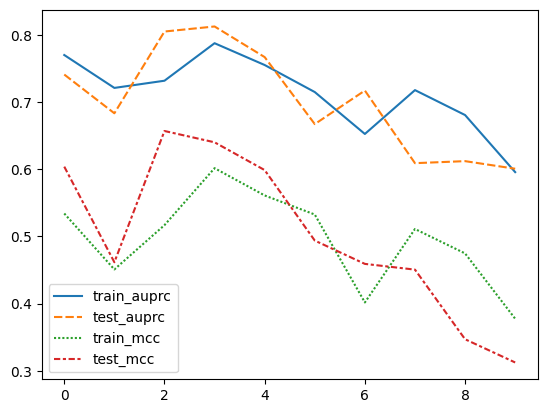

In [115]:
sns.lineplot(scores);

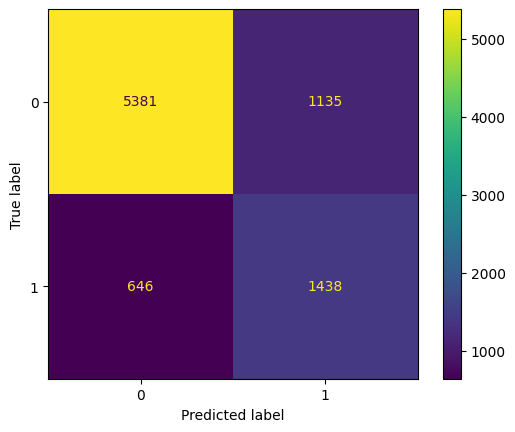

In [116]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [113]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

border = dt.date(2026, 1, 1)
train_gap = dt.timedelta(days=180)

X_train = data.loc[((border - train_gap) < X.time.dt.date) & (X.time.dt.date < border) & (X.region_id == 10)].copy().drop(columns="time")
y_train = X_train.pop(target)

X_test = data.loc[(X.time.dt.date >= border) & (X.region_id == 10)].copy().drop(columns="time")
y_test = X_test.pop(target)

pipeline.fit(X_train, y_train)

train_pred = pipeline.predict(X_train)
test_pred = pipeline.predict(X_test)

train_mcc = matthews_corrcoef(y_train, train_pred)
test_mcc = matthews_corrcoef(y_test, test_pred)

print(f"{train_mcc=:.4f}, {test_mcc=:.4f}")

train_mcc=0.4700, test_mcc=0.0000


# Try some parameters tunning

## Choosing loss function

loss='hinge'
------------- Fold 0 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2022-10-21 11:00:00+03:00
Test:  2022-10-28 12:00:00+03:00 - 2023-07-01 13:00:00+03:00
Train size: 5740, Test size: 5904
Train positive rate: 0.199, Test positive rate: 0.130
Training... Done.
Evaluating... Done.
Completed in 0.09s.
------------- Fold 1 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2023-06-24 13:00:00+03:00
Test:  2023-07-01 14:00:00+03:00 - 2024-03-03 14:00:00+02:00
Train size: 11644, Test size: 5904
Train positive rate: 0.167, Test positive rate: 0.206
Training... Done.
Evaluating... Done.
Completed in 0.09s.
------------- Fold 2 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2024-02-25 14:00:00+02:00
Test:  2024-03-03 15:00:00+02:00 - 2024-11-04 16:00:00+02:00
Train size: 17548, Test size: 5904
Train positive rate: 0.179, Test positive rate: 0.301
Training... Done.
Evaluating... Done.
Completed in 0.12s.
------------- Fold 3 -------------
Time ran

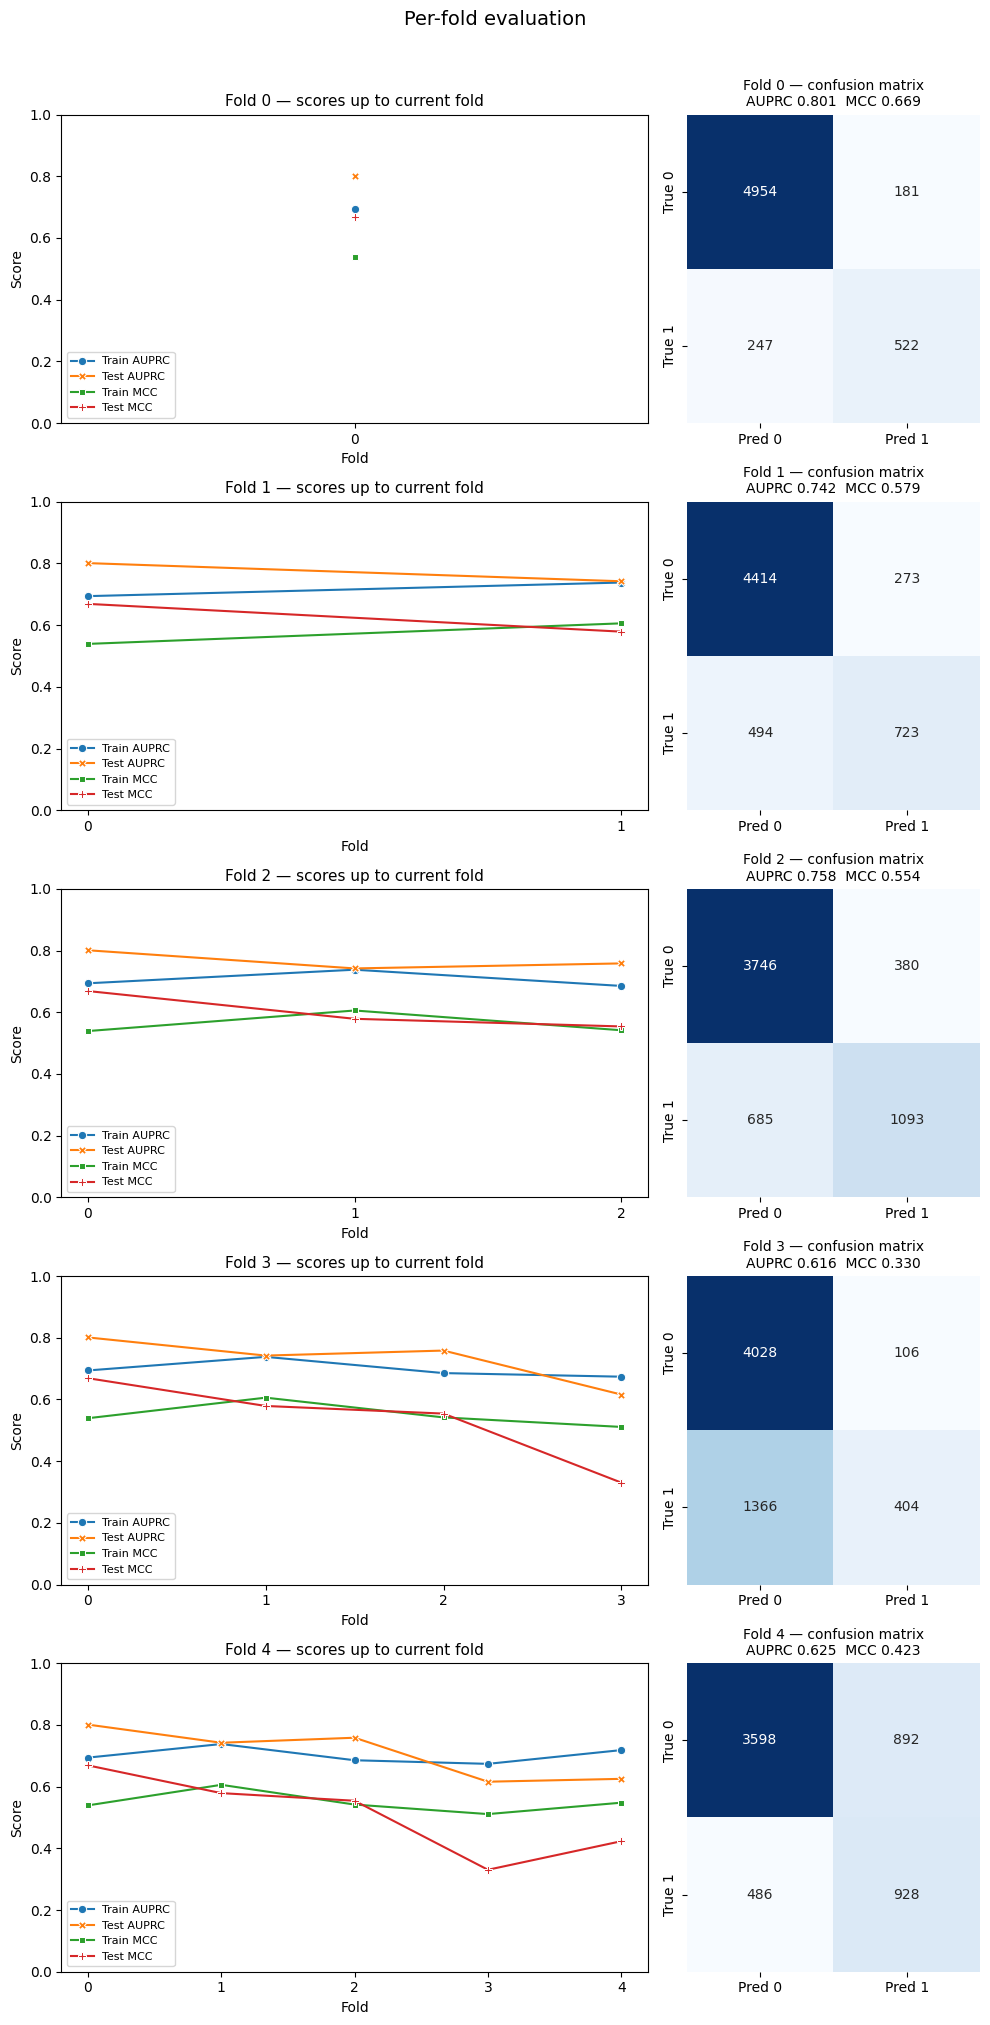


------------- Completed -------------
Train AUPRC : 0.702 ± 0.023
Test  AUPRC : 0.708 ± 0.074
Train MCC   : 0.549 ± 0.031
Test  MCC   : 0.511 ± 0.031
Completed in: 1.95s.

loss='log_loss'
------------- Fold 0 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2022-10-21 11:00:00+03:00
Test:  2022-10-28 12:00:00+03:00 - 2023-07-01 13:00:00+03:00
Train size: 5740, Test size: 5904
Train positive rate: 0.199, Test positive rate: 0.130
Training... Done.
Evaluating... Done.
Completed in 0.08s.
------------- Fold 1 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2023-06-24 13:00:00+03:00
Test:  2023-07-01 14:00:00+03:00 - 2024-03-03 14:00:00+02:00
Train size: 11644, Test size: 5904
Train positive rate: 0.167, Test positive rate: 0.206
Training... Done.
Evaluating... Done.
Completed in 0.10s.
------------- Fold 2 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2024-02-25 14:00:00+02:00
Test:  2024-03-03 15:00:00+02:00 - 2024-11-04 16:00:00+02:00
Train size: 17

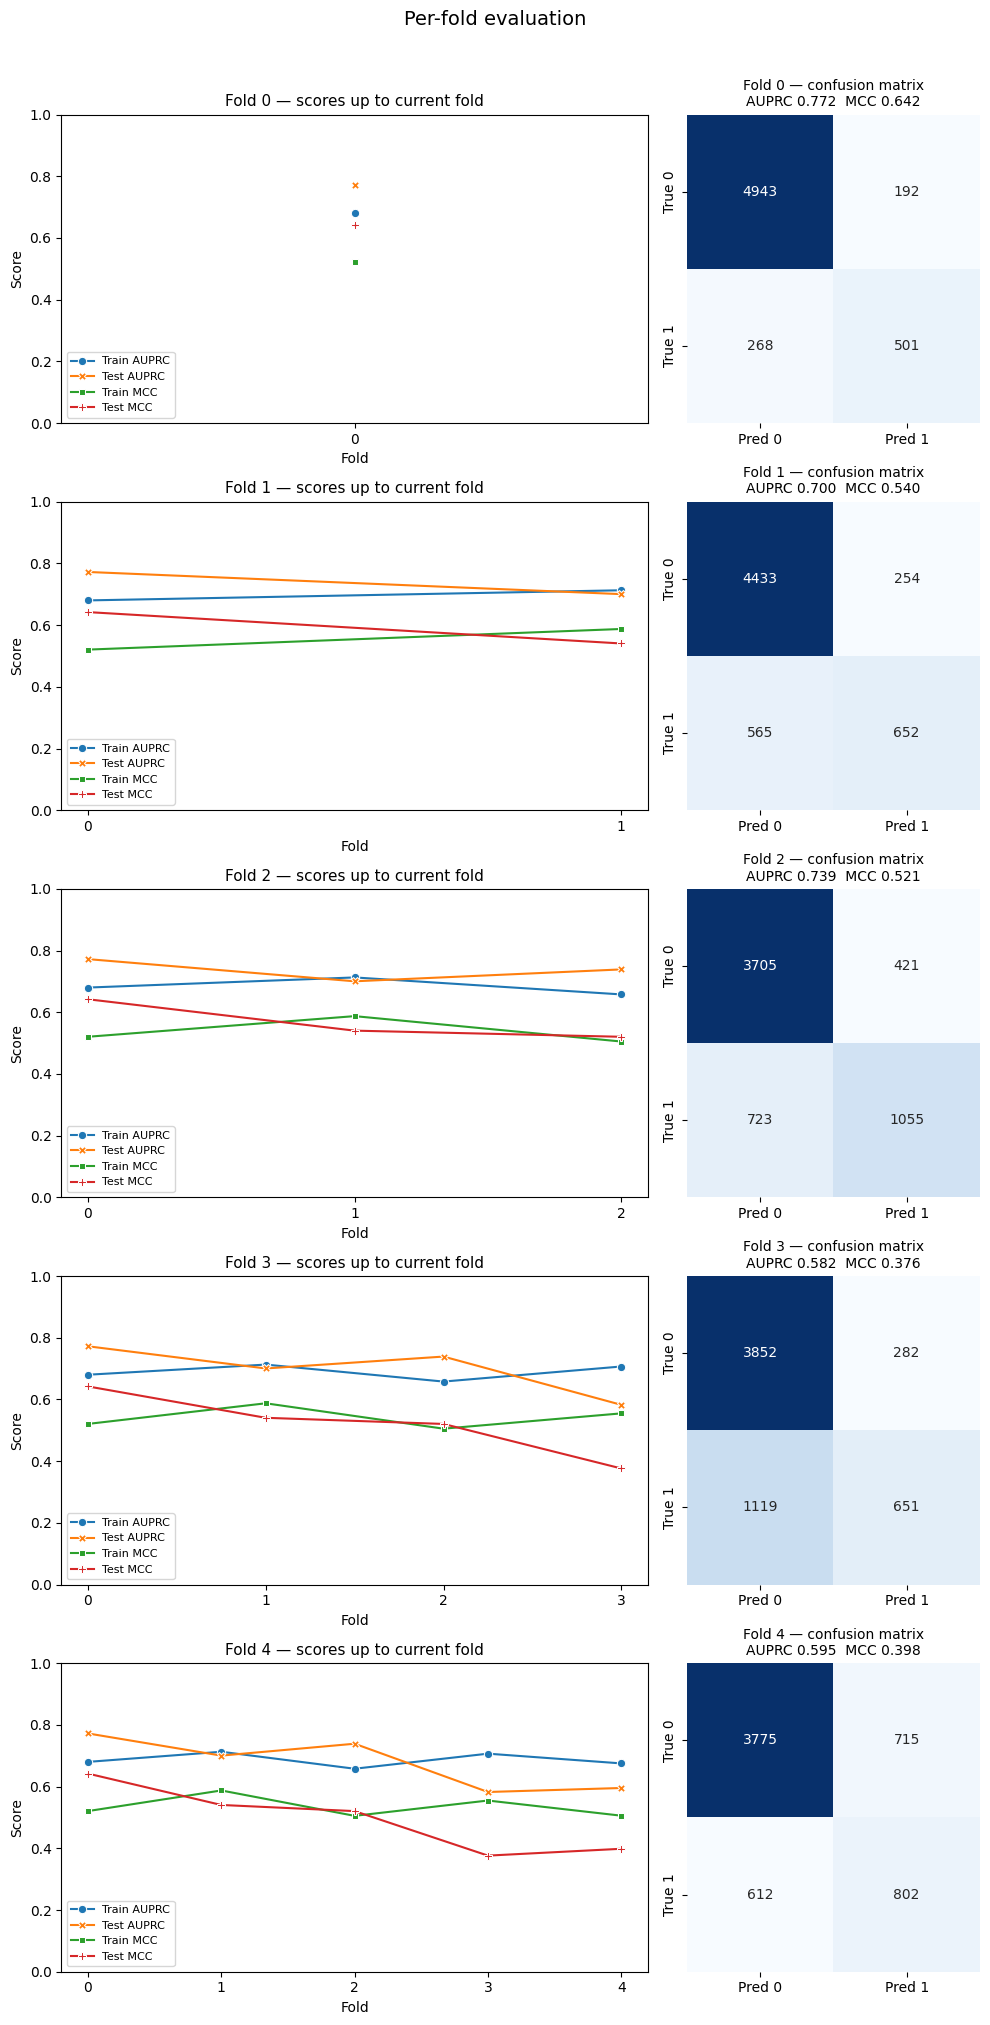


------------- Completed -------------
Train AUPRC : 0.687 ± 0.020
Test  AUPRC : 0.678 ± 0.076
Train MCC   : 0.535 ± 0.032
Test  MCC   : 0.496 ± 0.032
Completed in: 1.91s.

loss='modified_huber'
------------- Fold 0 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2022-10-21 11:00:00+03:00
Test:  2022-10-28 12:00:00+03:00 - 2023-07-01 13:00:00+03:00
Train size: 5740, Test size: 5904
Train positive rate: 0.199, Test positive rate: 0.130
Training... Done.
Evaluating... Done.
Completed in 0.08s.
------------- Fold 1 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2023-06-24 13:00:00+03:00
Test:  2023-07-01 14:00:00+03:00 - 2024-03-03 14:00:00+02:00
Train size: 11644, Test size: 5904
Train positive rate: 0.167, Test positive rate: 0.206
Training... Done.
Evaluating... Done.
Completed in 0.13s.
------------- Fold 2 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2024-02-25 14:00:00+02:00
Test:  2024-03-03 15:00:00+02:00 - 2024-11-04 16:00:00+02:00
Train si

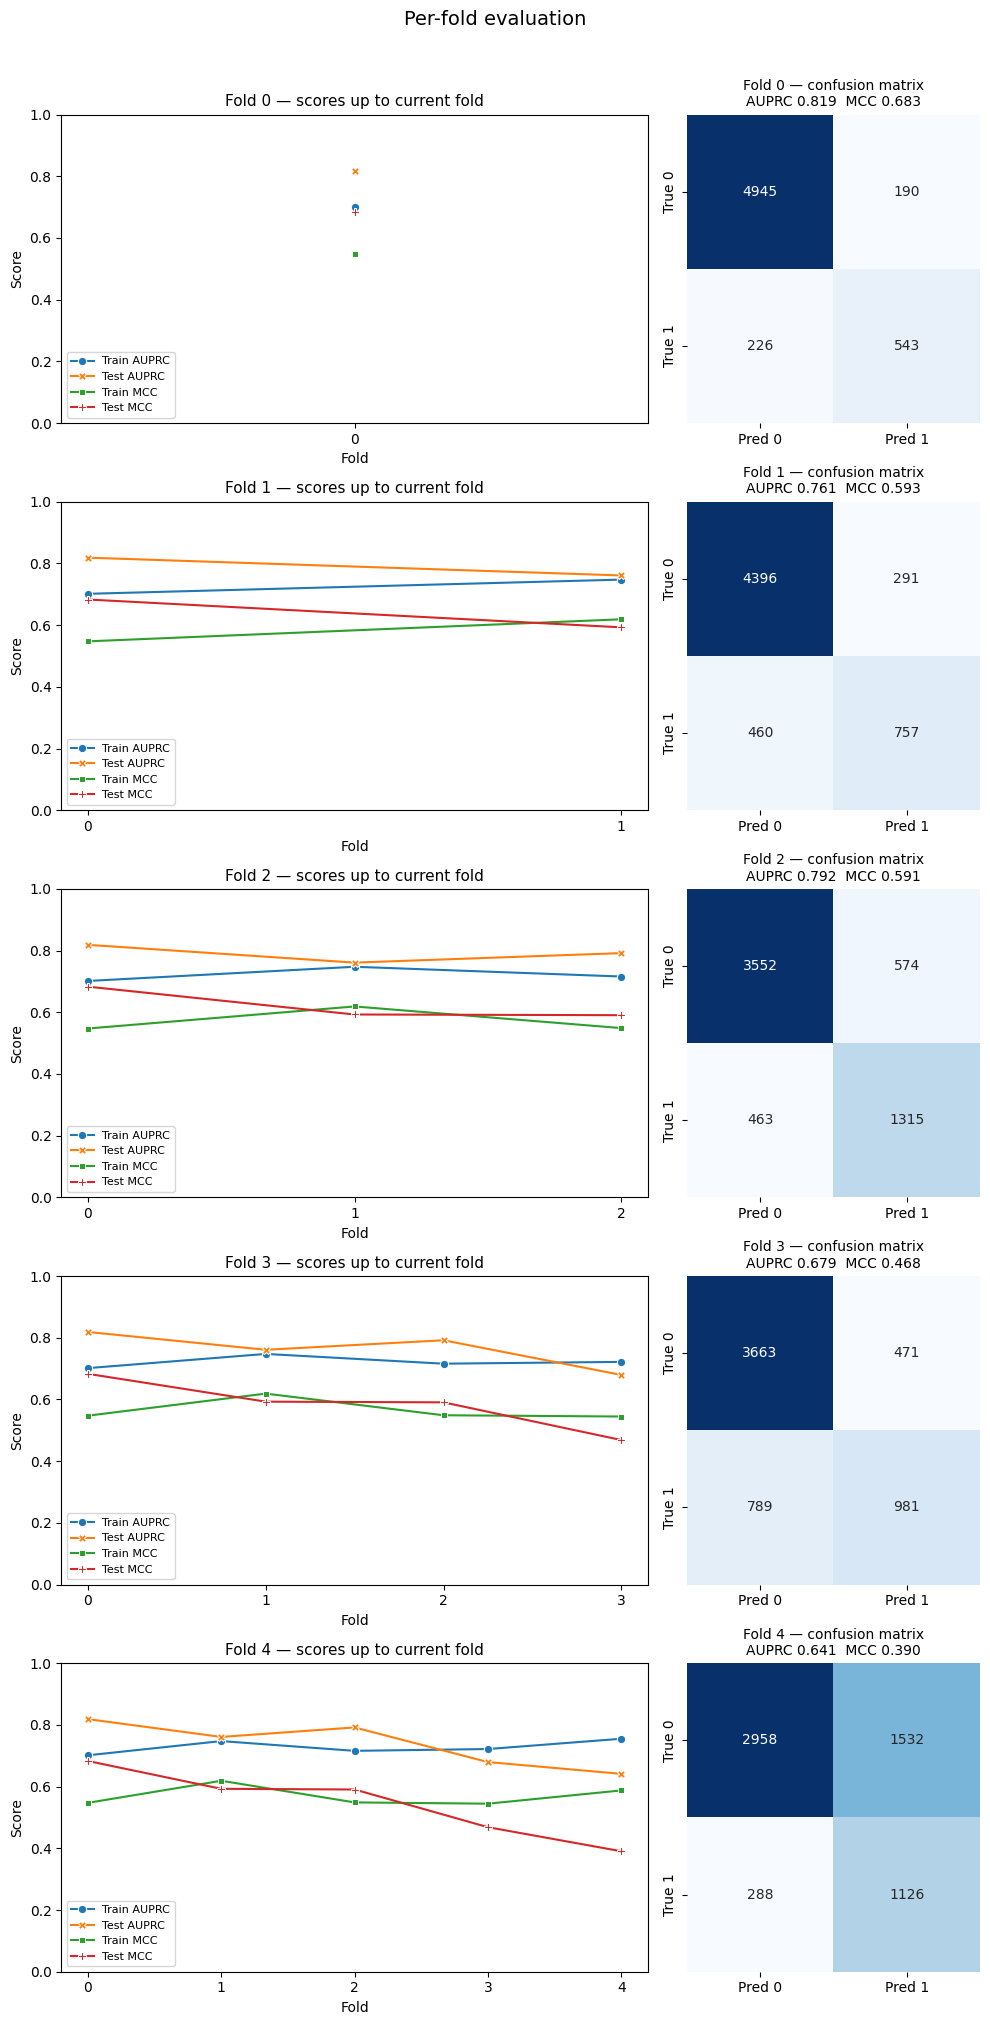


------------- Completed -------------
Train AUPRC : 0.728 ± 0.020
Test  AUPRC : 0.738 ± 0.067
Train MCC   : 0.569 ± 0.029
Test  MCC   : 0.545 ± 0.029
Completed in: 2.11s.



In [222]:
loss_funcs = ["hinge", "log_loss", "modified_huber"]
mcc_scores = pd.DataFrame()

for loss_func in loss_funcs:
    
    print(f"loss='{loss_func}'")
    model = SGDClassifier(random_state=42,
                          loss=loss_func,
                          shuffle=False)
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores, _ = evaluate_model(pipeline, X=X_1_reg, y=y_1_reg, use_sample_weights=True, half_life=120)
    # mcc_scores[f"{loss_func}_train"] = scores["train_mcc"]
    mcc_scores[f"{loss_func}_test"] = scores["test_mcc"]
    print()

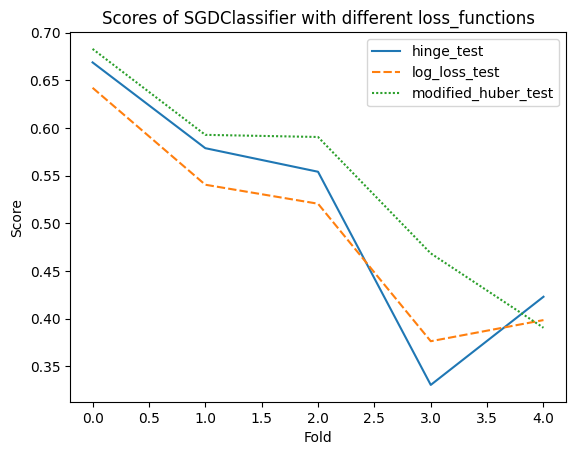

In [223]:
sns.lineplot(mcc_scores)

plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Scores of SGDClassifier with different loss_functions")
plt.show()

`modified_huber` performed the best

## loss='modified_huber'

------------- Fold 0 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2022-10-21 11:00:00+03:00
Test:  2022-10-28 12:00:00+03:00 - 2023-07-01 13:00:00+03:00
Train size: 5740, Test size: 5904
Train positive rate: 0.199, Test positive rate: 0.130
Training... Done.
Evaluating... Done.
Completed in 0.07s.
------------- Fold 1 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2023-06-24 13:00:00+03:00
Test:  2023-07-01 14:00:00+03:00 - 2024-03-03 14:00:00+02:00
Train size: 11644, Test size: 5904
Train positive rate: 0.167, Test positive rate: 0.206
Training... Done.
Evaluating... Done.
Completed in 0.15s.
------------- Fold 2 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2024-02-25 14:00:00+02:00
Test:  2024-03-03 15:00:00+02:00 - 2024-11-04 16:00:00+02:00
Train size: 17548, Test size: 5904
Train positive rate: 0.179, Test positive rate: 0.301
Training... Done.
Evaluating... Done.
Completed in 0.11s.
------------- Fold 3 -------------
Time range
Train: 202

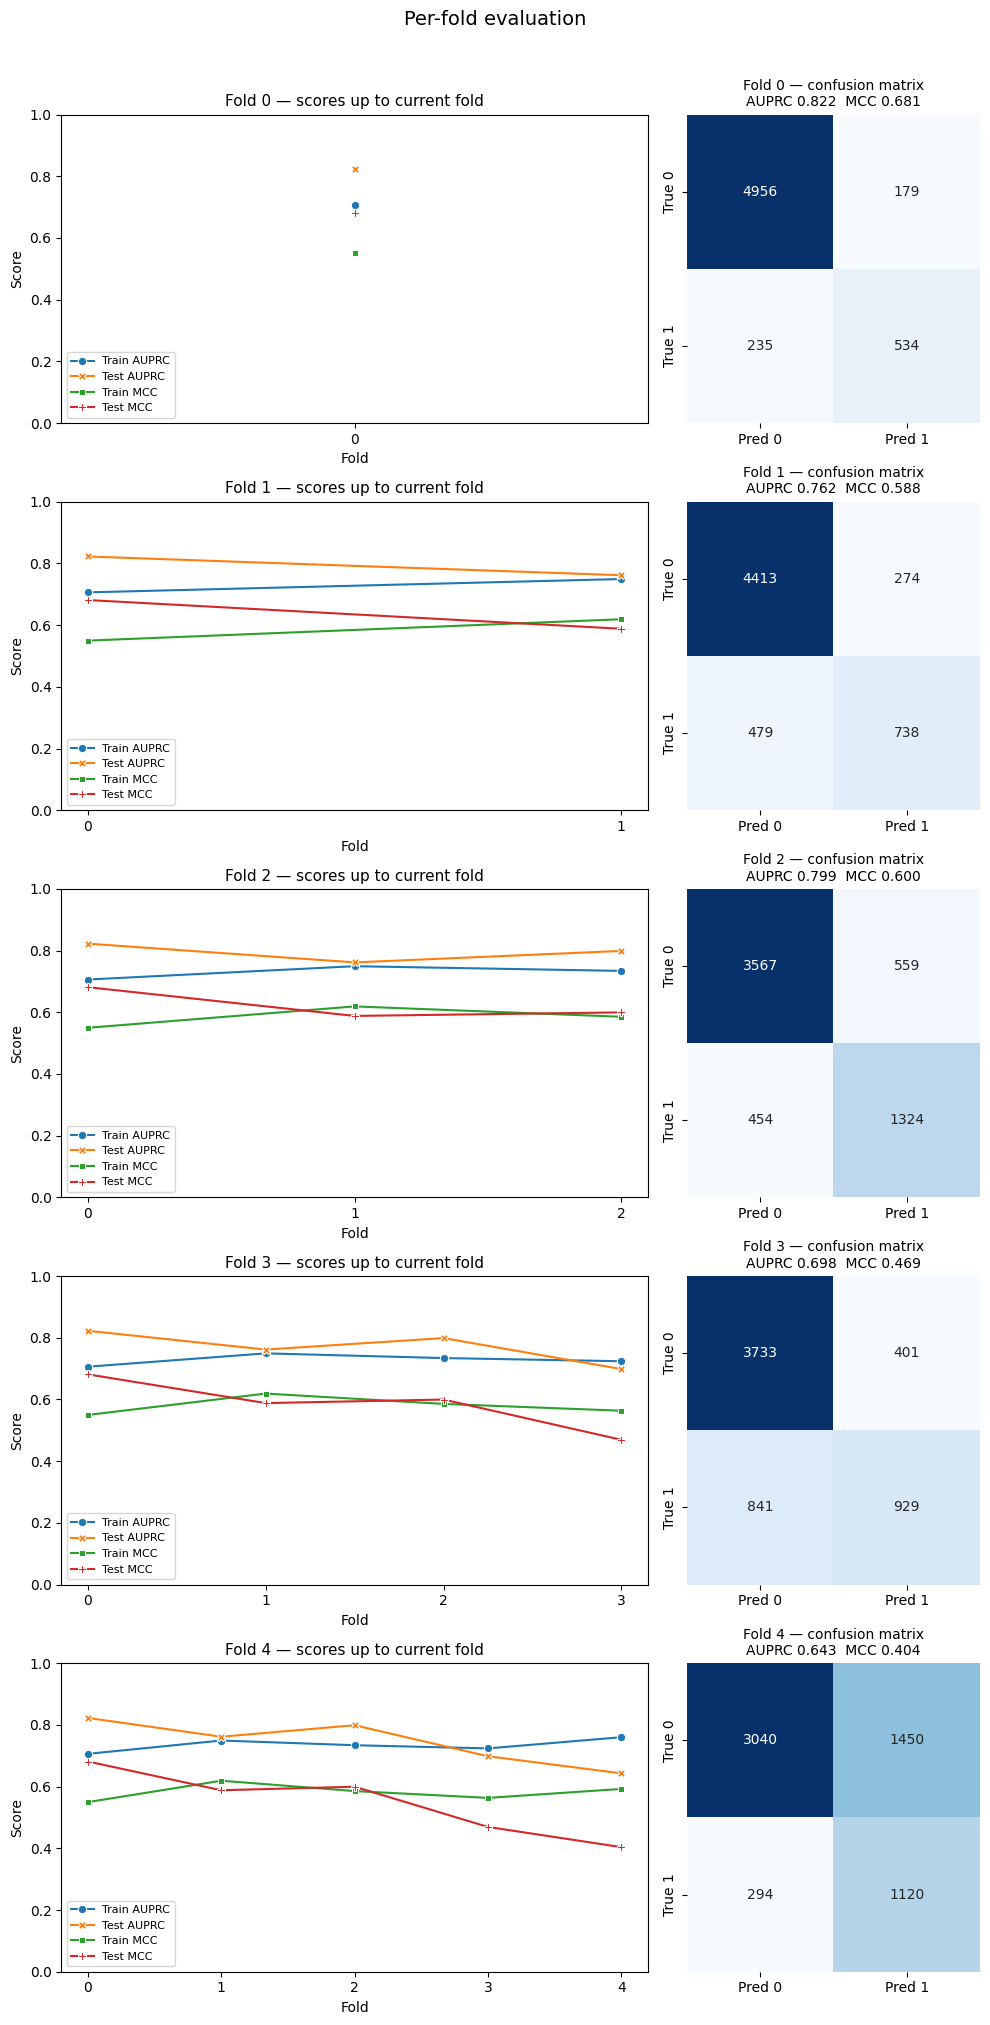


------------- Completed -------------
Train AUPRC : 0.735 ± 0.019
Test  AUPRC : 0.745 ± 0.066
Train MCC   : 0.582 ± 0.024
Test  MCC   : 0.548 ± 0.024
Completed in: 2.38s.


In [224]:
model = SGDClassifier(
    random_state=42,
    loss='modified_huber',
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores_log_loss, cm_log_loss = evaluate_model(pipeline, X=X_1_reg, y=y_1_reg, use_sample_weights=True, half_life=120)

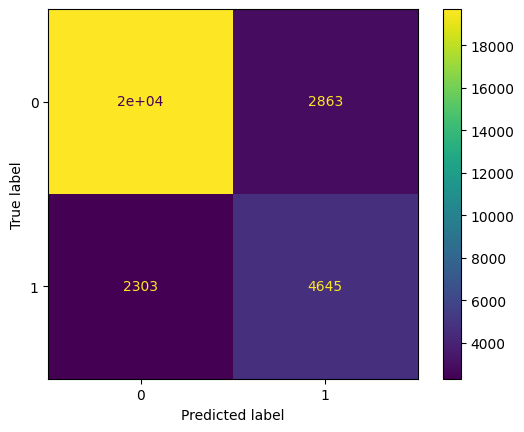

In [225]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log_loss)
disp.plot()
plt.show()

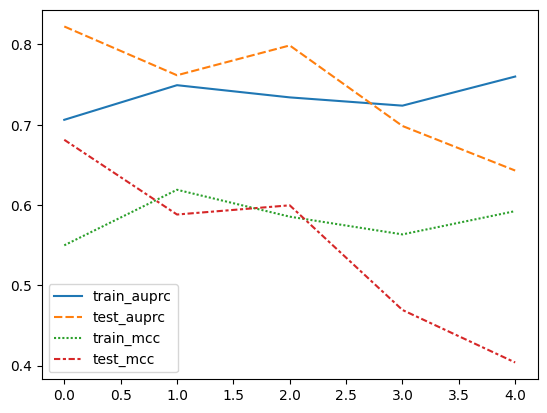

In [226]:
sns.lineplot(scores_log_loss);


## More parametes

    loss='log_loss',
    n_iter_no_change=5,
    validation_fraction=0.1,
    alpha=0.01,
    tol=1e-3,
    class_weight='balanced'

------------- Fold 0 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2022-10-21 11:00:00+03:00
Test:  2022-10-28 12:00:00+03:00 - 2023-07-01 13:00:00+03:00
Train size: 5740, Test size: 5904
Train positive rate: 0.199, Test positive rate: 0.130
Training... Done.
Evaluating... Done.
Completed in 0.11s.
------------- Fold 1 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2023-06-24 13:00:00+03:00
Test:  2023-07-01 14:00:00+03:00 - 2024-03-03 14:00:00+02:00
Train size: 11644, Test size: 5904
Train positive rate: 0.167, Test positive rate: 0.206
Training... Done.
Evaluating... Done.
Completed in 0.18s.
------------- Fold 2 -------------
Time range
Train: 2022-02-24 07:00:00+02:00 - 2024-02-25 14:00:00+02:00
Test:  2024-03-03 15:00:00+02:00 - 2024-11-04 16:00:00+02:00
Train size: 17548, Test size: 5904
Train positive rate: 0.179, Test positive rate: 0.301
Training... Done.
Evaluating... Done.
Completed in 0.21s.
------------- Fold 3 -------------
Time range
Train: 202

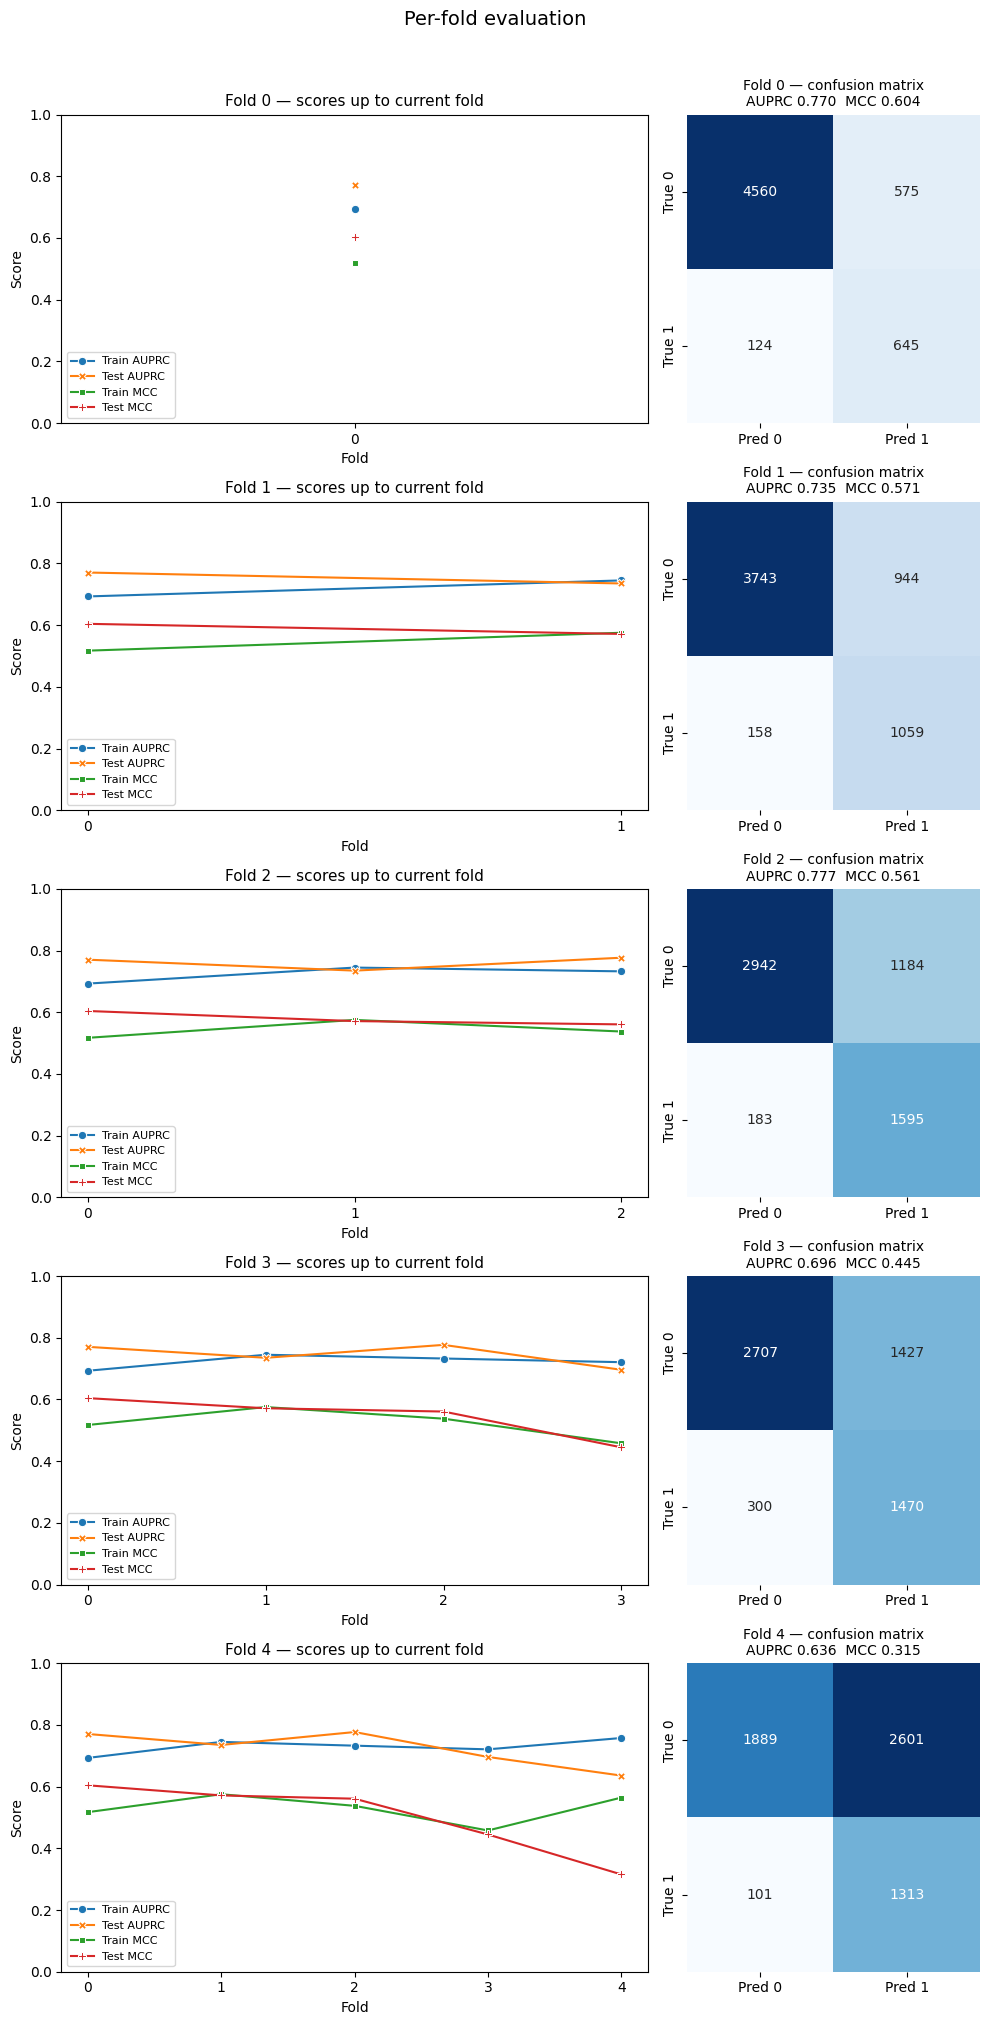


------------- Completed -------------
Train AUPRC : 0.730 ± 0.022
Test  AUPRC : 0.723 ± 0.052
Train MCC   : 0.530 ± 0.042
Test  MCC   : 0.499 ± 0.042
Completed in: 2.32s.


In [234]:
model = SGDClassifier(
    random_state=42,
    loss='modified_huber',
    shuffle=False,
    # early_stopping=True,
    # n_iter_no_change=5,
    # max_iter=1000,
    learning_rate='adaptive',
    power_t=0.1,
    eta0=0.01,
    # validation_fraction=0.1,
    alpha=1e-5,
    # tol=1e-2,
    class_weight='balanced',
    average=100
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores, cm = evaluate_model(pipeline, X=X_1_reg, y=y_1_reg, use_sample_weights=True, half_life=60)

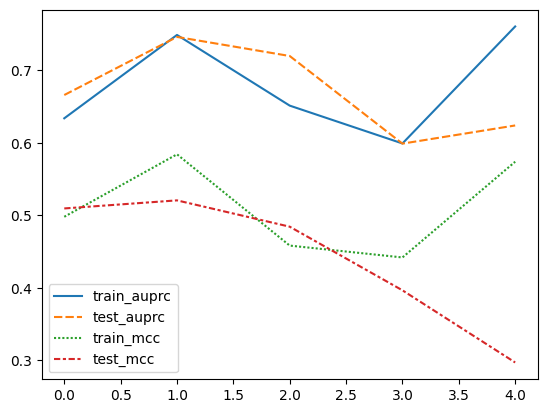

In [232]:
sns.lineplot(scores);

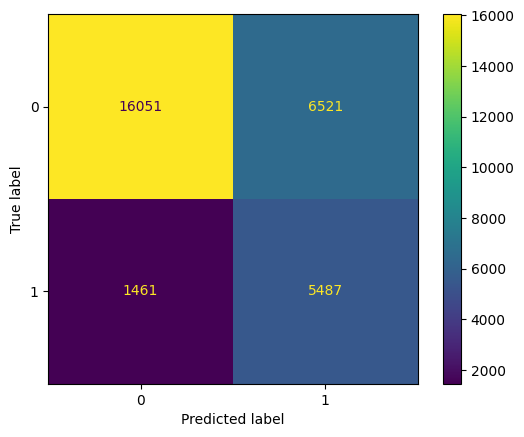

In [233]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

This model is better than previuos, because it make less wrong prediction when true value is 1. Cost of that is more wrong predictions for true value 0, but for our problem it is better to wrongly predict that there will be an alarm when it won't than vice versa say that there won't be an alarm when it will be.

# Final model

Chose my best last model as final variant

In [166]:
model = SGDClassifier(
    random_state=42,
    loss='log_loss',
    early_stopping=True,
    n_iter_no_change=5,
    max_iter=300,
    # learning_rate='adaptive',
    # power_t=0.1,
    # eta0=0.01,
    # validation_fraction=0.1,
    alpha=0.1,
    # tol=1e-2,
    class_weight='balanced',
    shuffle=False,
    average=True
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# pipeline.fit(X, y)

Try different training

In [167]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_1_reg.drop(columns="time"), y, test_size=0.2)

pipeline.fit(X_train, y_train)

train_pred = pipeline.predict(X_train)
test_pred = pipeline.predict(X_test)

train_score = matthews_corrcoef(y_train, train_pred)
test_score = matthews_corrcoef(y_test, test_pred)

print(f"MCC | train: {train_score}, test: {test_score}")

ValueError: Found input variables with inconsistent numbers of samples: [35428, 734233]

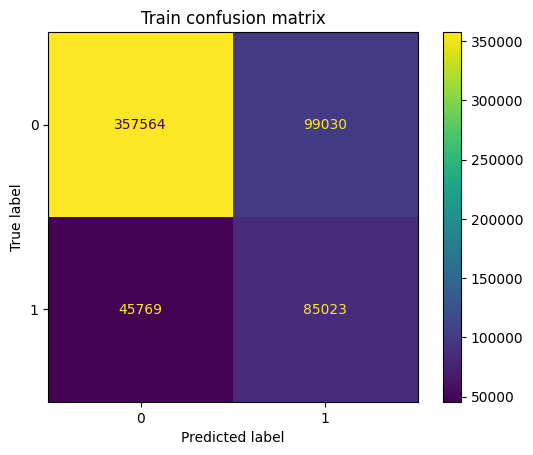

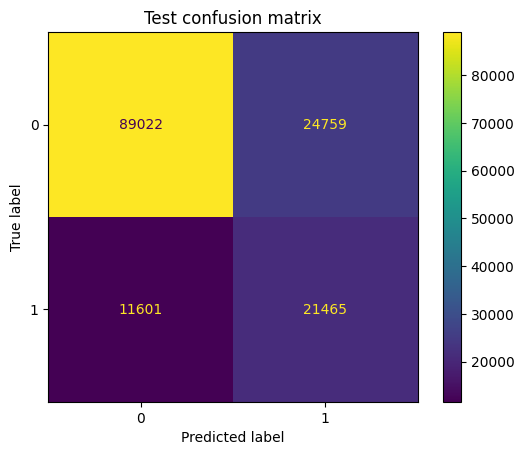

In [56]:
train_cm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_train, train_pred))
test_cm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, test_pred))

train_cm.plot()
plt.title("Train confusion matrix")

test_cm.plot()
plt.title("Test confusion matrix")

plt.show()

almost same results as before

## What the metrics mean

**Confusion Matrix cells:**
- **TN (True Negative):** Correctly predicted class 0 - Train: 392,266 | Test: 97,974
- **FP (False Positive):** Predicted 1, actually 0 - Train: 90,846 | Test: 22,792
- **FN (False Negative):** Predicted 0, actually 1 - Train: 38,960 | Test: 9,780
- **TP (True Positive):** Correctly predicted class 1 - Train: 85,647 | Test: 21,384

**MCC (Matthews Correlation Coefficient):**
- Ranges from -1 (worst) to +1 (perfect), 0 = random
- Train: **0.444**, Test: **0.442** - moderate predictive ability
- MCC is robust to class imbalance (class 0 is ~3× larger than class 1)

**Key observations:**
- High FP (90k train) - model over-predicts positive class, but for our needs it is better than fn
- Train ≈ Test scores - **no significant overfitting**

## Final training and saving

In [33]:
import pickle
from pathlib import Path

pipeline.fit(X.drop(columns="time"), y)

print("Training...")
models_dir = Path("app/models")

if not models_dir.exists():
    models_dir.mkdir(exist_ok=True, parents=True)

print("Saving...")
with open(models_dir / "SGDClassifier_v1.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Success.")

Training...
Saving...
Success.


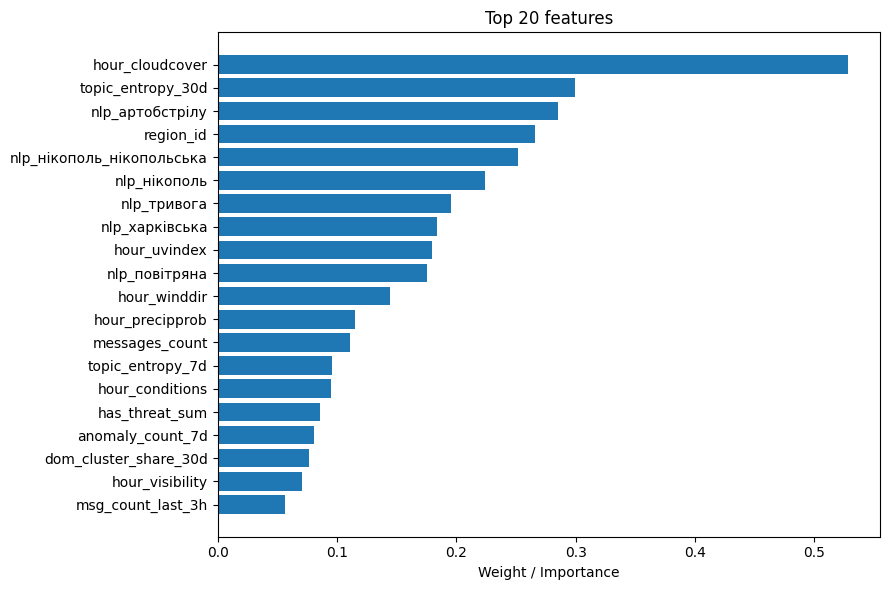

In [34]:
def get_top_features(pipeline, feature_names, top_n=20):
    """Extract top N features and their weights from a fitted pipeline."""
    model = pipeline.named_steps["model"]
    
    # Tree-based models
    if hasattr(model, "feature_importances_"):
        weights = model.feature_importances_
    # Linear models (coef_ is 2D for multi-class, 1D for binary)
    elif hasattr(model, "coef_"):
        weights = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim > 1 else np.abs(model.coef_[0])
    else:
        raise ValueError("Model has no feature_importances_ or coef_")

    indices = np.argsort(weights)[::-1][:top_n]
    return [(feature_names[i], weights[i]) for i in indices]

def get_feature_names_from_pipeline(pipeline):
    """Works when pipeline has a ColumnTransformer step named 'preprocessor'."""
    ct = pipeline.named_steps["preprocessor"]
    return ct.get_feature_names_out()


top_features = get_top_features(pipeline, X.columns, top_n=20)

fig = plt.figure(figsize=(9, 6))
names, weights = zip(*top_features)
plt.barh(names[::-1], weights[::-1])
plt.title("Top 20 features")
plt.xlabel("Weight / Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [43]:
coefficients.reshape(coefficients.shape[1])

array([-2.65699315e-01,  3.24828283e-03, -7.25887477e-03, -8.91203768e-03,
        1.65227896e-02,  1.97145753e-02,  2.67829964e-02,  1.15496851e-01,
       -4.85932369e-02,  3.42197818e-02,  1.44558317e-01, -5.18778870e-02,
       -7.07295597e-02,  5.28499256e-01,  1.79457943e-01, -9.50483798e-02,
        1.10944395e-01, -8.54213379e-02,  2.85091888e-01,  4.80183282e-02,
        2.17896354e-02,  4.11175305e-02, -1.67098239e-02,  1.02776566e-04,
       -5.87530046e-04,  2.23703528e-01,  2.51575011e-01,  2.31008823e-03,
        1.75299491e-01,  2.36542374e-02,  1.95404503e-01,  2.74265081e-03,
       -1.83967440e-01, -5.62912788e-02,  6.73228607e-03,  2.51220961e-03,
       -1.66723915e-02, -2.53546863e-02,  2.70950768e-02,  1.36137446e-02,
        1.07646102e-02, -1.92815036e-02,  0.00000000e+00,  9.54783185e-02,
        9.64082693e-03,  5.32879542e-02,  2.90176818e-02, -8.07648274e-02,
        2.50496613e-02,  7.13464869e-03,  2.99612994e-01,  7.66894603e-02,
       -8.10501959e-03,  

In [44]:
feature_names = X.drop(columns="time").columns

coefficients = pipeline.named_steps["model"].coef_
coefficients = coefficients.reshape(coefficients.shape[1])

coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": coefficients
})

coef_df["abs_weight"] = coef_df["weight"].abs()

top20 = coef_df.sort_values("abs_weight", ascending=False).head(20)

top20

,feature,weight,abs_weight
13,hour_uvindex,0.528499,0.528499
50,dom_cluster_share_30d,0.299613,0.299613
18,nlp_бпла,0.285092,0.285092
0,region_id,-0.265699,0.265699
26,nlp_нікопольська,0.251575,0.251575
25,nlp_нікополь_нікопольська,0.223704,0.223704
30,nlp_тривоги,0.195405,0.195405
32,msg_count_last_3h,-0.183967,0.183967
14,hour_conditions,0.179458,0.179458
28,nlp_повітряна_тривога,0.175299,0.175299


C:\Users\Георгій\AppData\Local\Temp\ipykernel_12856\1900941865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


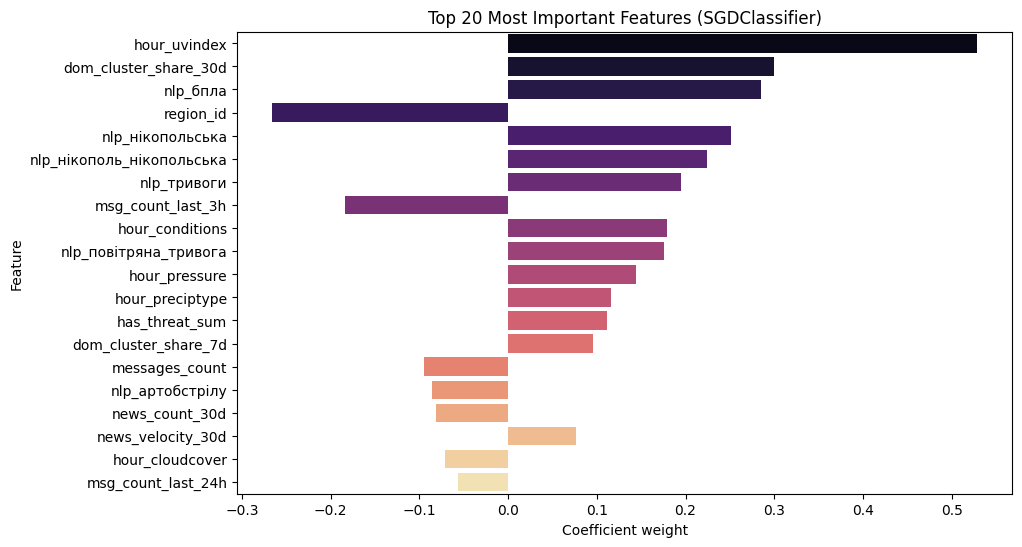

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top20,
    x="weight",
    y="feature",
    palette='magma'
)

plt.title("Top 20 Most Important Features (SGDClassifier)")
plt.xlabel("Coefficient weight")
plt.ylabel("Feature")

plt.show()